# 01 - Cleaning, RFM Segmentation, Cohort Retention and Delivery Impact

**Project:** Olist E-Commerce Profitability and Customer Retention Analysis

**Input:** the SQL view `vw_order_analysis` (one row per order, created in `sql/03_create_analysis_view.sql`)

**Sections**
1. Load data
2. Data cleaning (with before/after log)
3. RFM customer segmentation
4. Cohort retention analysis
5. Delivery delay vs review score (hypothesis test) and revenue at risk
6. Key findings and exports for Power BI

> Currency note: all values are in Brazilian reais (R$).

## 1. Load data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
from sqlalchemy import create_engine

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

DATA_DIR = Path(r"C:\Projects\olist-ecommerce-analysis\data")
engine = create_engine("mysql+pymysql://root:@localhost:3306/olist")

df = pd.read_sql("SELECT * FROM vw_order_analysis", engine)

# MariaDB returns DECIMAL as Python Decimal objects, so convert to real numbers
num_cols = ["delivery_days", "delay_days", "is_late", "items_count",
            "items_revenue", "freight_total", "payment_value_total", "review_score"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c])
for c in ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]:
    df[c] = pd.to_datetime(df[c])

df.to_csv(DATA_DIR / "order_analysis.csv", index=False)
print("Shape:", df.shape)
df.head()

Shape: (99441, 17)


,order_id,customer_unique_id,customer_city,customer_state,order_status,order_purchase_timestamp,order_month,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,is_late,items_count,items_revenue,freight_total,payment_value_total,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,delivered,2017-09-13 08:59:02,2017-09,2017-09-20 23:43:48,2017-09-29,7.00,-9.00,0.00,1.00,58.90,13.29,72.19,5.00
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,delivered,2017-04-26 10:53:06,2017-04,2017-05-12 16:04:24,2017-05-15,16.00,-3.00,0.00,1.00,239.90,19.93,259.83,4.00
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,delivered,2018-01-14 14:33:31,2018-01,2018-01-22 13:19:16,2018-02-05,8.00,-14.00,0.00,1.00,199.00,17.87,216.87,5.00
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP,delivered,2018-08-08 10:00:35,2018-08,2018-08-14 13:32:39,2018-08-20,6.00,-6.00,0.00,1.00,12.99,12.79,25.78,4.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP,delivered,2017-02-04 13:57:51,2017-02,2017-03-01 16:42:31,2017-03-17,25.00,-16.00,0.00,1.00,199.90,18.14,218.04,5.00


## 2. Data cleaning

First inspect the problems, then fix them step by step and record the row counts.

In [2]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Duplicate order_id rows:", df.duplicated("order_id").sum())
print()
print("Order status counts:")
print(df["order_status"].value_counts())

Missing values per column:
order_id                            0
customer_unique_id                  0
customer_city                       0
customer_state                      0
order_status                        0
order_purchase_timestamp            0
order_month                         0
order_delivered_customer_date    2965
order_estimated_delivery_date       0
delivery_days                    2965
delay_days                       2965
is_late                          2965
items_count                       775
items_revenue                     775
freight_total                     775
payment_value_total                 1
review_score                      768
dtype: int64

Duplicate order_id rows: 0

Order status counts:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [3]:
# Which orders have no delivery date? (explains the 2,965 missing values)
pd.crosstab(df["order_status"], df["order_delivered_customer_date"].isna(),
            rownames=["order_status"], colnames=["missing_delivery_date"])

missing_delivery_date,False,True
order_status,,
approved,0,2
canceled,6,619
created,0,5
delivered,96470,8
invoiced,0,314
processing,0,301
shipped,0,1107
unavailable,0,609


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
from sqlalchemy import create_engine

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

DATA_DIR = Path(r"C:\Projects\olist-ecommerce-analysis\data")
engine = create_engine("mysql+pymysql://root:@localhost:3306/olist")

df = pd.read_sql("SELECT * FROM vw_order_analysis", engine)

# MariaDB returns DECIMAL as Python Decimal objects, so convert to real numbers
num_cols = ["delivery_days", "delay_days", "is_late", "items_count",
            "items_revenue", "freight_total", "payment_value_total", "review_score"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c])
for c in ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]:
    df[c] = pd.to_datetime(df[c])

df.to_csv(DATA_DIR / "order_analysis.csv", index=False)
print("Shape:", df.shape)
df.head()

Shape: (99441, 17)


,order_id,customer_unique_id,customer_city,customer_state,order_status,order_purchase_timestamp,order_month,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,is_late,items_count,items_revenue,freight_total,payment_value_total,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,delivered,2017-09-13 08:59:02,2017-09,2017-09-20 23:43:48,2017-09-29,7.00,-9.00,0.00,1.00,58.90,13.29,72.19,5.00
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,delivered,2017-04-26 10:53:06,2017-04,2017-05-12 16:04:24,2017-05-15,16.00,-3.00,0.00,1.00,239.90,19.93,259.83,4.00
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,delivered,2018-01-14 14:33:31,2018-01,2018-01-22 13:19:16,2018-02-05,8.00,-14.00,0.00,1.00,199.00,17.87,216.87,5.00
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP,delivered,2018-08-08 10:00:35,2018-08,2018-08-14 13:32:39,2018-08-20,6.00,-6.00,0.00,1.00,12.99,12.79,25.78,4.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP,delivered,2017-02-04 13:57:51,2017-02,2017-03-01 16:42:31,2017-03-17,25.00,-16.00,0.00,1.00,199.90,18.14,218.04,5.00


In [4]:
# Cleaning log: keep a record of every step with before/after row counts
log = []
def record(step, before, after):
    log.append({"step": step, "rows_before": before, "rows_after": after, "rows_removed": before - after})

d = df.copy()

n = len(d); d = d[d["order_status"] == "delivered"]
record("Keep delivered orders only (cancelled/unavailable/in-transit have no completed sale)", n, len(d))

n = len(d); d = d[d["order_delivered_customer_date"].notna()]
record("Drop delivered orders with no delivery date", n, len(d))

n = len(d); d = d[d["items_revenue"].notna()]
record("Drop orders with no item records", n, len(d))

n = len(d); d = d[d["delivery_days"] >= 0]
record("Drop orders delivered before purchase (invalid dates)", n, len(d))

pd.DataFrame(log)

,step,rows_before,rows_after,rows_removed
0,Keep delivered orders only (cancelled/unavaila...,99441,96478,2963
1,Drop delivered orders with no delivery date,96478,96470,8
2,Drop orders with no item records,96470,96470,0
3,Drop orders delivered before purchase (invalid...,96470,96470,0


In [5]:
# Outlier detection with the IQR rule. Decision: FLAG, do not remove.
# Reason: high prices, heavy freight and long deliveries are real business events.
# The hypothesis test later is rank-based, so it is robust to outliers.
def iqr_bounds(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

rows = []
for col in ["items_revenue", "freight_total", "delivery_days"]:
    lo, hi = iqr_bounds(d[col])
    flag = f"{col}_outlier"
    d[flag] = (d[col] < lo) | (d[col] > hi)
    rows.append({"column": col, "lower_bound": lo, "upper_bound": hi,
                 "outliers": int(d[flag].sum()), "pct_of_rows": d[flag].mean() * 100})
pd.DataFrame(rows)

,column,lower_bound,upper_bound,outliers,pct_of_rows
0,items_revenue,-110.10,305.90,7658,7.94
1,freight_total,-1.40,39.27,9694,10.05
2,delivery_days,-6.50,29.50,4729,4.90


Orders with no review: 646
Clean dataset: (96470, 20)


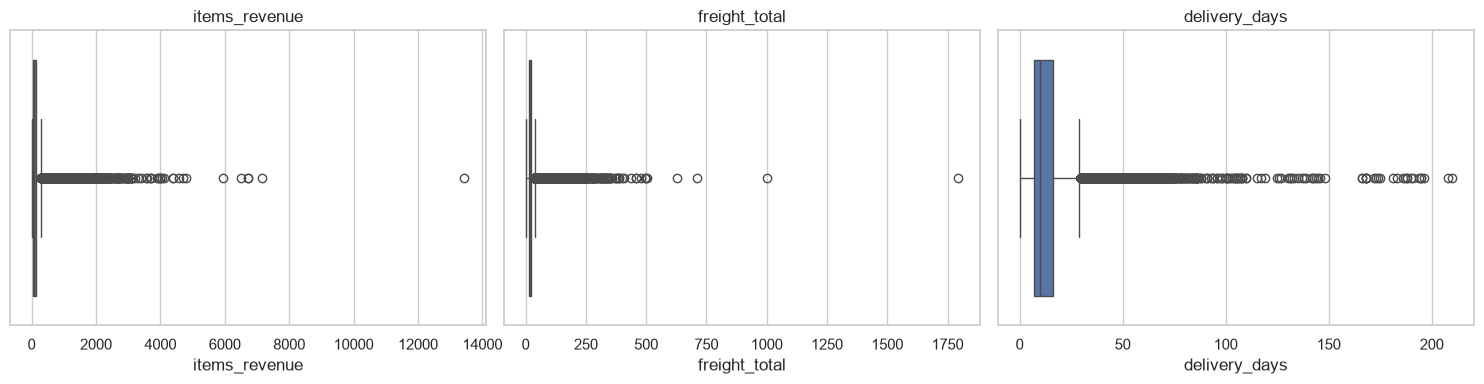

In [6]:
# Missing review scores: keep the orders, exclude them only from review analysis
print("Orders with no review:", d["review_score"].isna().sum())
print("Clean dataset:", d.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["items_revenue", "freight_total", "delivery_days"]):
    sns.boxplot(x=d[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Monthly revenue trend (clean data)

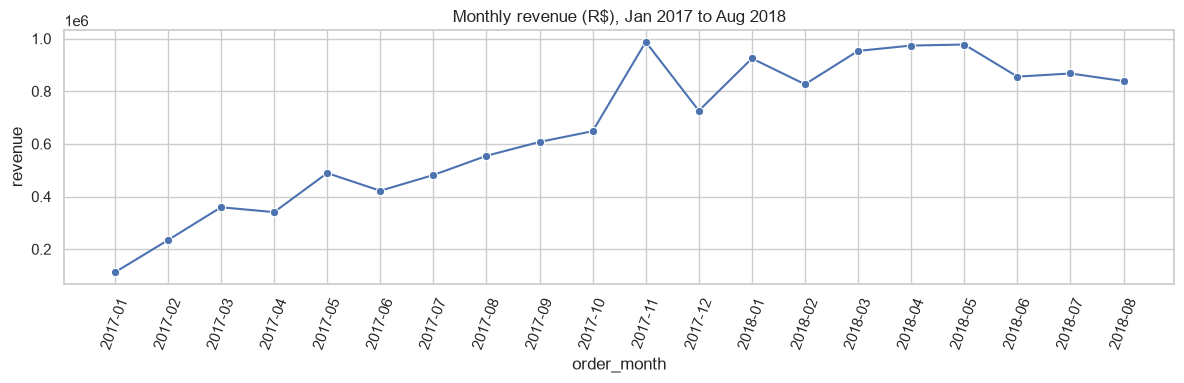

In [7]:
monthly = (d.groupby("order_month")
             .agg(orders=("order_id", "nunique"), revenue=("items_revenue", "sum"))
             .reset_index())
monthly = monthly[(monthly["order_month"] >= "2017-01") & (monthly["order_month"] <= "2018-08")]

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(data=monthly, x="order_month", y="revenue", marker="o", ax=ax)
ax.set_title("Monthly revenue (R$), Jan 2017 to Aug 2018")
ax.tick_params(axis="x", rotation=70)
plt.tight_layout()
plt.show()

## 3. RFM customer segmentation

- **Recency:** days since the customer's last order (lower is better)
- **Frequency:** number of orders
- **Monetary:** total spend on items

Customers are identified by `customer_unique_id` (the real person).
`customer_id` changes with every order, so it cannot be used.
Because about 97% of customers order only once, frequency is scored on a 1 to 3 scale
(1 order, 2 orders, 3 or more) rather than in quintiles.

In [8]:
snapshot = d["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (d.groupby("customer_unique_id")
         .agg(last_purchase=("order_purchase_timestamp", "max"),
              frequency=("order_id", "nunique"),
              monetary=("items_revenue", "sum"))
         .reset_index())
rfm["recency"] = (snapshot - rfm["last_purchase"]).dt.days

# Scores: rank first so ties do not break the quantile cut
rfm["R"] = pd.qcut(rfm["recency"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["F"] = np.where(rfm["frequency"] >= 3, 3, np.where(rfm["frequency"] == 2, 2, 1))

def segment(row):
    if row["F"] >= 2 and row["R"] >= 4:
        return "Champions"          # repeat buyers who bought recently
    if row["F"] >= 2:
        return "Repeat (lapsing)"   # repeat buyers, not recent
    if row["R"] >= 4:
        return "New customers"      # one order, very recent
    if row["R"] == 3:
        return "Needs attention"
    if row["R"] == 2:
        return "At risk"
    return "Lost"                   # one order, long ago

rfm["segment"] = rfm.apply(segment, axis=1)
rfm.head()

,customer_unique_id,last_purchase,frequency,monetary,recency,R,M,F,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,129.90,112,4,4,1,New customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,18.90,115,4,1,1,New customers
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,69.00,537,1,2,1,Lost
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,25.99,321,2,1,1,At risk
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,180.00,288,2,5,1,At risk


In [9]:
seg = (rfm.groupby("segment")
          .agg(customers=("customer_unique_id", "count"),
               avg_recency_days=("recency", "mean"),
               avg_orders=("frequency", "mean"),
               avg_spend=("monetary", "mean"),
               revenue=("monetary", "sum")))
seg["pct_customers"] = seg["customers"] / seg["customers"].sum() * 100
seg["pct_revenue"] = seg["revenue"] / seg["revenue"].sum() * 100
seg = seg.sort_values("revenue", ascending=False)
seg

,customers,avg_recency_days,avg_orders,avg_spend,revenue,pct_customers,pct_revenue
segment,,,,,,,
New customers,36132,90.42,1.00,140.30,"5,069,292.46",38.71,38.34
At risk,18110,315.89,1.00,141.13,"2,555,813.06",19.40,19.33
Lost,18234,473.45,1.00,138.09,"2,517,913.27",19.53,19.05
Needs attention,18073,219.94,1.00,129.96,"2,348,821.39",19.36,17.77
Repeat (lapsing),1593,319.79,2.08,252.55,"402,305.03",1.71,3.04
Champions,1208,89.09,2.15,269.95,"326,103.72",1.29,2.47


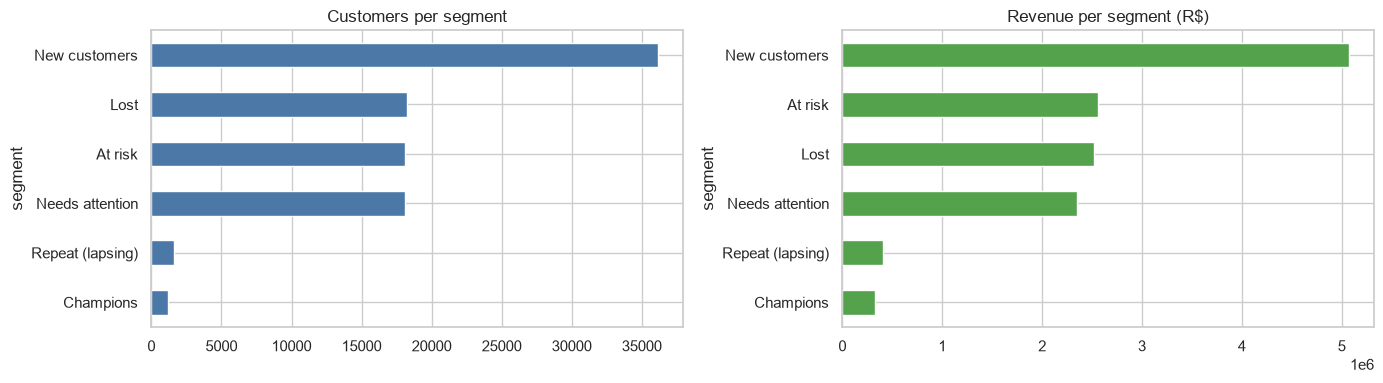

Repeat purchase rate: 3.00% of customers ordered more than once


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
seg["customers"].sort_values().plot.barh(ax=axes[0], color="#4C78A8")
axes[0].set_title("Customers per segment")
seg["revenue"].sort_values().plot.barh(ax=axes[1], color="#54A24B")
axes[1].set_title("Revenue per segment (R$)")
plt.tight_layout()
plt.show()

repeat_rate = (rfm["frequency"] > 1).mean() * 100
print(f"Repeat purchase rate: {repeat_rate:.2f}% of customers ordered more than once")

## 4. Cohort retention analysis

A cohort is the group of customers who made their first purchase in the same month.
Retention in month N is the share of that cohort that ordered again N months later.
Cohorts from Jan 2017 to Jun 2018 are shown, because earlier cohorts are tiny.

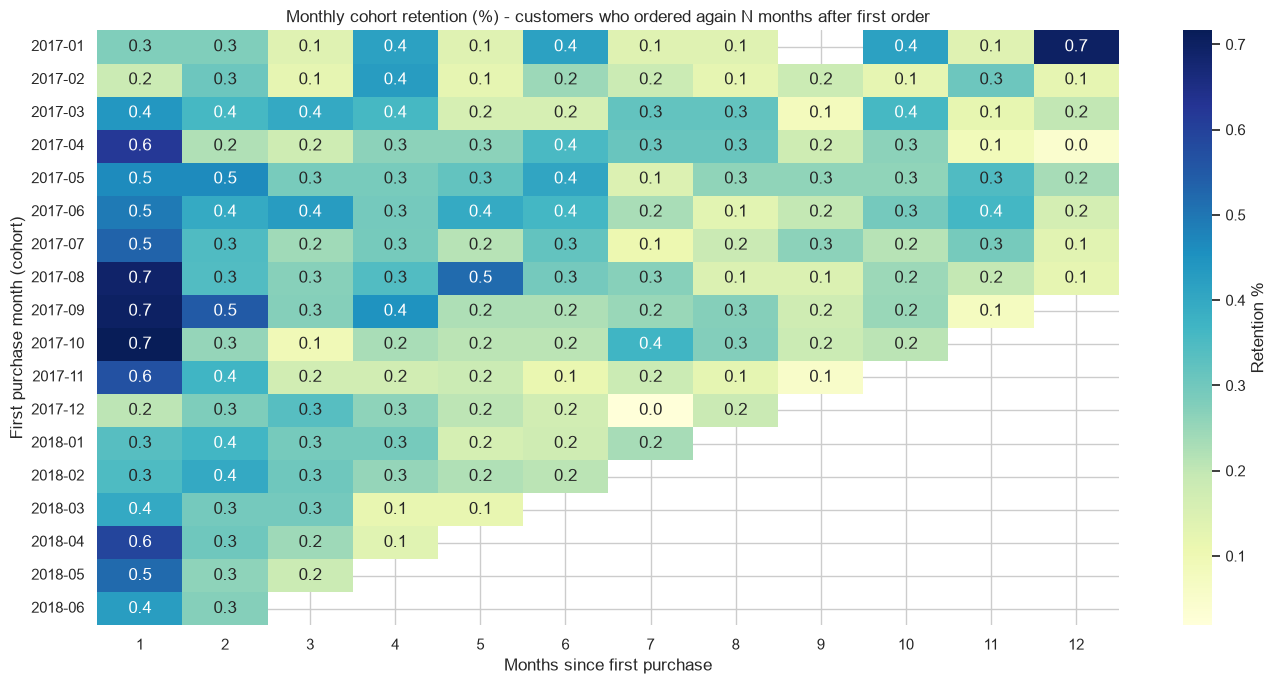

Average month-1 retention: 0.47%
Average month-3 retention: 0.25%


In [11]:
d["order_period"] = d["order_purchase_timestamp"].dt.to_period("M")
first_period = d.groupby("customer_unique_id")["order_period"].min().rename("cohort")
c = d.join(first_period, on="customer_unique_id")

c["cohort_index"] = ((c["order_period"].dt.year - c["cohort"].dt.year) * 12
                     + (c["order_period"].dt.month - c["cohort"].dt.month))

cohort_counts = (c.groupby(["cohort", "cohort_index"])["customer_unique_id"]
                  .nunique().unstack())
cohort_counts = cohort_counts.loc["2017-01":"2018-06"]

retention = cohort_counts.div(cohort_counts[0], axis=0) * 100
retention.index = retention.index.astype(str)

# Month 0 is always 100%, so it is left out of the heatmap
plot_data = retention.iloc[:, 1:13]
plt.figure(figsize=(14, 7))
sns.heatmap(plot_data, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "Retention %"})
plt.title("Monthly cohort retention (%) - customers who ordered again N months after first order")
plt.xlabel("Months since first purchase")
plt.ylabel("First purchase month (cohort)")
plt.tight_layout()
plt.show()

print("Average month-1 retention: {:.2f}%".format(retention[1].mean()))
print("Average month-3 retention: {:.2f}%".format(retention[3].mean()))

## 5. Delivery delay vs review score

**Question:** Do late deliveries lower customer review scores?

- H0: review scores are the same for late and on-time orders
- H1: review scores are lower for late orders

Review scores are ordinal and heavily skewed (most are 5 stars), so they are not normally distributed.
The **Mann-Whitney U test** is used instead of a t-test.

In [12]:
r = d[d["review_score"].notna()].copy()
r["delivery_status"] = np.where(r["is_late"] == 1, "Late", "On time")

summary = (r.groupby("delivery_status")["review_score"]
             .agg(orders="count", mean_score="mean", median_score="median"))
summary["pct_low_reviews_1_or_2"] = r.groupby("delivery_status")["review_score"].apply(lambda s: (s <= 2).mean() * 100)
summary

,orders,mean_score,median_score,pct_low_reviews_1_or_2
delivery_status,,,,
Late,6381,2.27,1.00,62.36
On time,89443,4.29,5.00,9.23


In [13]:
late = r.loc[r["is_late"] == 1, "review_score"]
on_time = r.loc[r["is_late"] == 0, "review_score"]

u_stat, p_value = stats.mannwhitneyu(late, on_time, alternative="less")
rank_biserial = 2 * u_stat / (len(late) * len(on_time)) - 1   # negative = late orders score lower

print(f"Late orders:    n={len(late):,}, mean={late.mean():.2f}")
print(f"On-time orders: n={len(on_time):,}, mean={on_time.mean():.2f}")
print(f"Mean difference: {late.mean() - on_time.mean():.2f} points")
print(f"Mann-Whitney U = {u_stat:,.0f}, p-value = {p_value:.3g}")
print(f"Effect size (rank-biserial) = {rank_biserial:.2f}")
print("Result:", "Reject H0 - late deliveries have significantly lower review scores"
      if p_value < 0.05 else "Fail to reject H0")

Late orders:    n=6,381, mean=2.27
On-time orders: n=89,443, mean=4.29
Mean difference: -2.02 points
Mann-Whitney U = 103,308,952, p-value = 0
Effect size (rank-biserial) = -0.64
Result: Reject H0 - late deliveries have significantly lower review scores


                  orders  mean_score  pct_low_reviews_1_or_2
delay_bucket                                                
On time or early   89443        4.29                    9.23
1-3 days late       1852        3.29                   32.18
4-7 days late       1748        2.11                   67.56
8+ days late        2781        1.70                   79.18


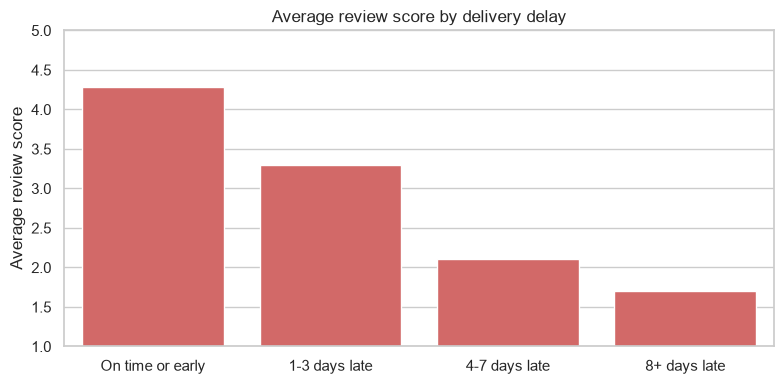

In [14]:
# How bad does it get as the delay grows?
r["delay_bucket"] = pd.cut(r["delay_days"],
                           bins=[-np.inf, 0, 3, 7, np.inf],
                           labels=["On time or early", "1-3 days late", "4-7 days late", "8+ days late"])
bucket = (r.groupby("delay_bucket", observed=True)["review_score"]
            .agg(orders="count", mean_score="mean"))
bucket["pct_low_reviews_1_or_2"] = r.groupby("delay_bucket", observed=True)["review_score"].apply(lambda s: (s <= 2).mean() * 100)
print(bucket)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=bucket.index.astype(str), y=bucket["mean_score"], color="#E45756", ax=ax)
ax.set_title("Average review score by delivery delay")
ax.set_ylabel("Average review score")
ax.set_xlabel("")
ax.set_ylim(1, 5)
plt.tight_layout()
plt.show()

In [15]:
# Revenue at risk: revenue from late orders that received a 1 or 2 star review
total_revenue = d["items_revenue"].sum()
risk_orders = r[(r["is_late"] == 1) & (r["review_score"] <= 2)]
revenue_at_risk = risk_orders["items_revenue"].sum()

print(f"Total delivered revenue:         R${total_revenue:,.0f}")
print(f"Late orders: {int((d['is_late'] == 1).sum()):,} ({(d['is_late'] == 1).mean() * 100:.1f}% of delivered orders)")
print(f"Late orders with 1-2 star review: {len(risk_orders):,}")
print(f"Revenue at risk:                 R${revenue_at_risk:,.0f} ({revenue_at_risk / total_revenue * 100:.1f}% of revenue)")

# Worst states for late delivery (states with 500+ orders)
state_late = (d.groupby("customer_state")
                .agg(orders=("order_id", "count"),
                     late_pct=("is_late", lambda s: s.mean() * 100),
                     avg_delivery_days=("delivery_days", "mean")))
state_late = state_late[state_late["orders"] >= 500].sort_values("late_pct", ascending=False)
state_late.head(10)

Total delivered revenue:         R$13,220,249
Late orders: 6,534 (6.8% of delivered orders)
Late orders with 1-2 star review: 3,979
Revenue at risk:                 R$618,573 (4.7% of revenue)


,orders,late_pct,avg_delivery_days
customer_state,,,
MA,717,17.43,21.51
CE,1279,13.76,21.20
BA,3256,12.16,19.28
RJ,12350,12.11,15.24
PA,946,11.21,23.73
ES,1995,10.73,15.72
PB,517,10.44,20.39
MS,701,9.70,15.54
PE,1593,9.60,18.40


## 6. Key findings and exports

The cell below prints the headline numbers. Copy them into the README and resume bullets.
The exported CSV files feed the Power BI dashboard.

In [16]:
print("KEY FINDINGS")
print("-" * 60)
print(f"Delivered orders analysed:         {len(d):,}")
print(f"Total revenue:                     R${total_revenue:,.0f}")
print(f"Repeat purchase rate:              {repeat_rate:.2f}%")
print(f"Average month-1 retention:         {retention[1].mean():.2f}%")
print(f"Late delivery rate:                {(d['is_late'] == 1).mean() * 100:.1f}%")
print(f"Avg review, late vs on-time:       {late.mean():.2f} vs {on_time.mean():.2f}  (p = {p_value:.3g})")
print(f"Revenue at risk (late + 1-2 star): R${revenue_at_risk:,.0f} ({revenue_at_risk / total_revenue * 100:.1f}%)")
print(f"One-time customers in 'Lost' or 'At risk': {seg.loc[['Lost', 'At risk'], 'customers'].sum():,}")

KEY FINDINGS
------------------------------------------------------------
Delivered orders analysed:         96,470
Total revenue:                     R$13,220,249
Repeat purchase rate:              3.00%
Average month-1 retention:         0.47%
Late delivery rate:                6.8%
Avg review, late vs on-time:       2.27 vs 4.29  (p = 0)
Revenue at risk (late + 1-2 star): R$618,573 (4.7%)
One-time customers in 'Lost' or 'At risk': 36,344


In [17]:
# Files for Power BI (saved in the data folder, which is excluded from Git)
rfm.to_csv(DATA_DIR / "rfm_customers.csv", index=False)
seg.reset_index().to_csv(DATA_DIR / "rfm_segments.csv", index=False)
retention.reset_index().to_csv(DATA_DIR / "cohort_retention.csv", index=False)
bucket.reset_index().to_csv(DATA_DIR / "delay_vs_review.csv", index=False)
d.to_csv(DATA_DIR / "orders_clean.csv", index=False)
print("Exported 5 CSV files to", DATA_DIR)

Exported 5 CSV files to C:\Projects\olist-ecommerce-analysis\data
